<a href="https://colab.research.google.com/github/1kilele/Data-science-/blob/main/World_Languages_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Ñimport pandas as pd
df=pd.read_csv("22_Languages_of_the_World.csv")
print(df.tail())
print(f"Dataset shape {df.shape[0]} rows, {df.shape[1]} columns")

            id           name macroarea  latitude  longitude iso639p3code  \
8607  punu1239           Punu    Africa  -2.67362    11.6714          puu   
8608  vumb1238          Vumbu    Africa  -2.17673    10.6498          vum   
8609  sang1333  Sangu (Gabon)    Africa  -1.52694    11.9098          snq   
8610  bara1362         Barama    Africa  -2.49659    10.6777          bbg   
8611  sira1266           Sira    Africa  -1.78084    10.4635          swj   

     countries  is_isolate family_id          family  status_code  \
8607     CG;GA       False  atla1278  Atlantic-Congo          1.0   
8608        GA       False  atla1278  Atlantic-Congo          3.0   
8609        GA       False  atla1278  Atlantic-Congo          1.0   
8610        GA       False  atla1278  Atlantic-Congo          2.0   
8611        GA       False  atla1278  Atlantic-Congo          1.0   

        status_label  
8607  not endangered  
8608        shifting  
8609  not endangered  
8610      threatened  
8611  n

In [ ]:
df["standalone"]=df["is_isolate"].map({True:1,"False":0})
df["standalone"]=df["standalone"].fillna(0)
print(df["standalone"].tail())

8607    0.0
8608    0.0
8609    0.0
8610    0.0
8611    0.0
Name: standalone, dtype: float64


In [ ]:
Languages_country=df["countries"].value_counts()
if "KE" in Languages_country:
   print(f"KE:{Languages_country['KE']}")
else:
   print("It doesn't exist")


ethnicity=df["macroarea"].value_counts()
print(ethnicity)

KE:43
macroarea
Africa                          2363
Papunesia                       2177
Eurasia                         2017
North America                    767
South America                    676
Australia                        381
Africa;Eurasia                     4
Eurasia;Papunesia                  1
Africa;North America               1
Africa;Eurasia;South America       1
Name: count, dtype: int64


In [ ]:
print(f"TZ:{Languages_country['TZ']}")
print("Enter the language you would want to locate")
lang=input()
if lang in df["name"].values:
  print(f"{lang} is one of the languages")
else:
  print(f"{lang} is not listed")

TZ:96
Enter the language you would want to locate
Langi
Langi is one of the languages


In [ ]:
Languages_condition=df["status_label"].value_counts()
print(Languages_condition)
Languages_condition_analysis=df.groupby("macroarea")["status_code"].mean()
print(Languages_condition_analysis)

status_label
not endangered    2704
shifting          1835
threatened        1629
extinct           1225
moribund           434
nearly extinct     311
Name: count, dtype: int64
macroarea
Africa                          1.884327
Africa;Eurasia                  1.500000
Africa;Eurasia;South America    1.000000
Africa;North America            1.000000
Australia                       5.274667
Eurasia                         2.649151
Eurasia;Papunesia               2.000000
North America                   3.689900
Papunesia                       2.329406
South America                   4.166154
Name: status_code, dtype: float64


In [ ]:
df["macroarea_value"]=df["macroarea"].map({"Africa":1,"Papunesia":2,"Eurasia":3,"North America":4,"South America":5,"Australia":6})
df["macroarea_value"]=df["macroarea_value"].fillna(0)
df["status_code"]=df["status_code"].fillna(0)
print(df["macroarea_value"])

0       2.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
8607    1.0
8608    1.0
8609    1.0
8610    1.0
8611    1.0
Name: macroarea_value, Length: 8612, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

X=df[["status_code","macroarea_value"]]
y=df["standalone"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=3)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
y=classification_report(y_test,prediction)
print(f"The model's accuracy is:{y}")
print(f"The accuracy score is {accuracy_score(y_test,prediction)}%")
print(confusion_matrix(y_test,prediction))






The model's accuracy is:              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1676
         1.0       0.97      0.83      0.90        47

    accuracy                           0.99      1723
   macro avg       0.99      0.91      0.95      1723
weighted avg       0.99      0.99      0.99      1723

The accuracy score is 0.9947765525246662%
[[1675    1]
 [   8   39]]


In [ ]:
print(y_test.value_counts())

standalone
0.0    1676
1.0      47
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
X=df[["status_code","macroarea_value"]]
y=df["standalone"]

model=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=3)
model.fit(X,y)

test_data=pd.DataFrame({"status_code":[1],"macroarea_value":[4]})
prediction=model.predict(test_data)
if prediction<=0:
  print("It is isolated")
else:
  print("Some family exist")

It is isolated


In [ ]:
all_countries=df['countries'].dropna().str.split(',').explode()
print(all_countries.value_counts()['KE'])
stat=df.groupby(all_countries)['standalone'].max()
print(stat)

43
countries
AD;AR;BO;BR;BZ;CL;CO;CR;CU;DO;EC;ES;FR;GI;GT;GY;HN;HT;MA;MX;NI;PA;PE;PR;PT;PY;SV;US;UY;VE    0.0
AD;AR;BO;BR;CO;ES;FR;GF;GY;PE;PT;PY;SR;UY;VE                                                 0.0
AD;BE;CA;CH;FR;GF;IT;LU;MC;PM;TF;US                                                          0.0
AD;ES;FR;IT                                                                                  0.0
AD;ES;FR;IT;MC                                                                               0.0
                                                                                            ... 
YE                                                                                           0.0
YT                                                                                           0.0
ZA                                                                                           0.0
ZM                                                                                           0.0
ZW               

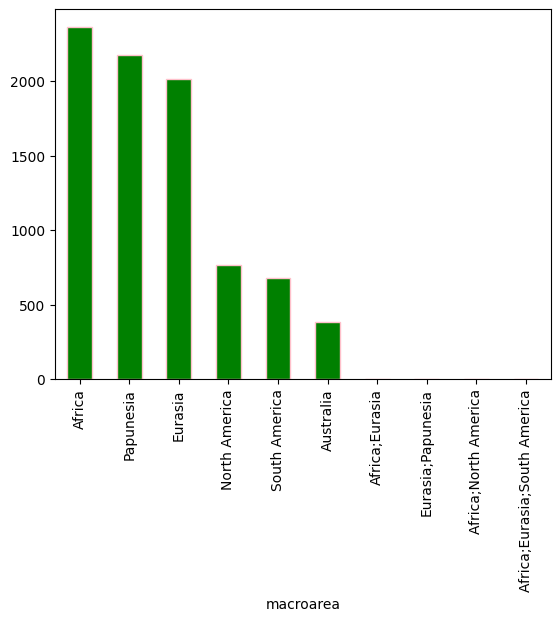

In [ ]:
import matplotlib.pyplot as plt
ethnicity.plot(kind="bar",color="green",edgecolor="pink")
plt.show()

<Axes: xlabel='status_label'>

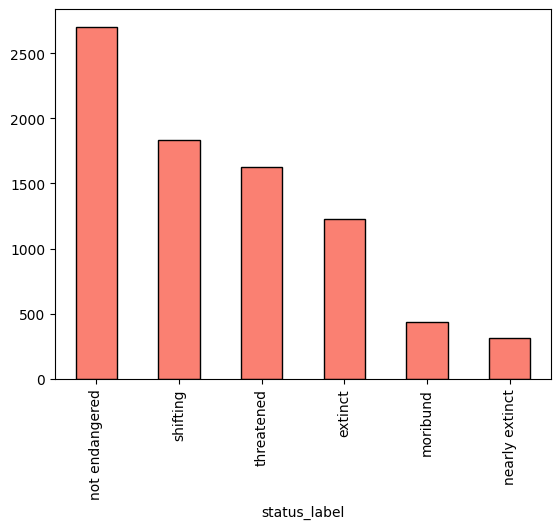

In [ ]:
Languages_condition.plot(kind="bar",color="salmon",edgecolor="black")

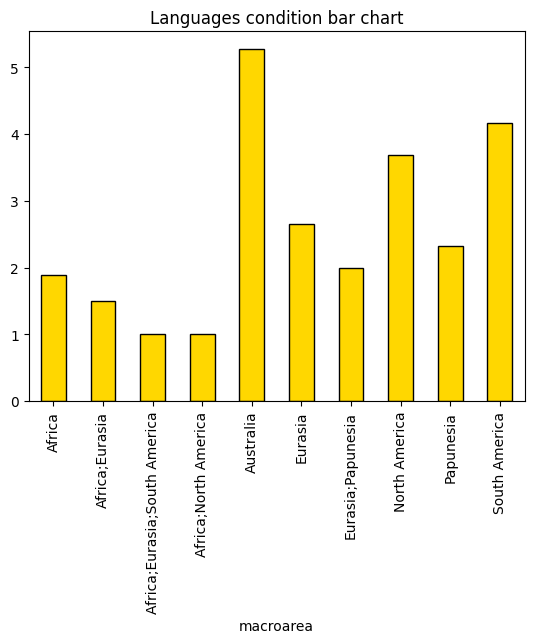

In [ ]:
Languages_condition_analysis.plot(kind="bar",color="gold",edgecolor="black")
plt.title("Languages condition bar chart")
plt.show()